# 🍷 Slooze Wine & Spirits — Inventory, Purchase & Sales Analysis
> **Author:** Data Science Candidate  
> **Dataset:** [sloozecareers/slooze-challenge](https://www.kaggle.com/datasets/sloozecareers/slooze-challenge)  
> **Scope:** Demand Forecasting · ABC Analysis · EOQ · Reorder Points · Lead Time · Bonus Insights

---

## 0. Setup & Data Loading

In [4]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn statsmodels plotly openpyxl

import warnings
warnings.filterwarnings('ignore')

import kagglehub
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
import math

# ── Global aesthetics ─────────────────────────────────────────────────────────
PALETTE = ['#7B2D8B', '#C0392B', '#E67E22', '#27AE60', '#2980B9', '#8E44AD']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)

print(' Libraries loaded successfully')

 Libraries loaded successfully


In [5]:
# ── Download dataset from Kaggle ──────────────────────────────────────────────
path = kagglehub.dataset_download('sloozecareers/slooze-challenge')
print('Dataset path:', path)

# List all CSV files
csv_files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
for f in csv_files:
    print(' -', os.path.basename(f))

Dataset path: C:\Users\akash\.cache\kagglehub\datasets\sloozecareers\slooze-challenge\versions\1
 - 2017PurchasePricesDec.csv
 - BegInvFINAL12312016.csv
 - EndInvFINAL12312016.csv
 - InvoicePurchases12312016.csv
 - PurchasesFINAL12312016.csv
 - SalesFINAL12312016.csv


In [6]:
# ── Load all CSVs into a dictionary ──────────────────────────────────────────
def load_csv(keyword):
    matches = [f for f in csv_files if keyword.lower() in f.lower()]
    if not matches:
        raise FileNotFoundError(f'No file matching "{keyword}" found.')
    df = pd.read_csv(matches[0], low_memory=False)
    print(f'  Loaded {os.path.basename(matches[0])}: {df.shape[0]:,} rows × {df.shape[1]} cols')
    return df

print('Loading datasets...')
beg_inv  = load_csv('BegInv')         # Beginning inventory
end_inv  = load_csv('EndInv')         # Ending inventory
purchases = load_csv('Purchases')     # Purchase transactions
sales    = load_csv('Sales')          # Sales transactions
invoices = load_csv('Invoice')        # Invoice / purchase prices
prices   = load_csv('PurchasePrice')  # 2017 purchase prices
print('All datasets loaded')

Loading datasets...
  Loaded BegInvFINAL12312016.csv: 206,529 rows × 9 cols
  Loaded EndInvFINAL12312016.csv: 224,489 rows × 9 cols
  Loaded InvoicePurchases12312016.csv: 5,543 rows × 10 cols
  Loaded SalesFINAL12312016.csv: 1,048,575 rows × 14 cols
  Loaded InvoicePurchases12312016.csv: 5,543 rows × 10 cols
  Loaded 2017PurchasePricesDec.csv: 12,261 rows × 9 cols
All datasets loaded


In [7]:
# ── Quick schema peek ─────────────────────────────────────────────────────────
datasets = {
    'Beginning Inventory': beg_inv,
    'Ending Inventory':    end_inv,
    'Purchases':           purchases,
    'Sales':               sales,
    'Invoices':            invoices,
    'Purchase Prices':     prices
}

for name, df in datasets.items():
    print(f'\n── {name} ─────────────────────')
    print(f'  Shape : {df.shape}')
    print(f'  Cols  : {list(df.columns)}')


── Beginning Inventory ─────────────────────
  Shape : (206529, 9)
  Cols  : ['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

── Ending Inventory ─────────────────────
  Shape : (224489, 9)
  Cols  : ['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']

── Purchases ─────────────────────
  Shape : (5543, 10)
  Cols  : ['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']

── Sales ─────────────────────
  Shape : (1048575, 14)
  Cols  : ['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity', 'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification', 'ExciseTax', 'VendorNo', 'VendorName']

── Invoices ─────────────────────
  Shape : (5543, 10)
  Cols  : ['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']

── Purchase Prices ──

---
## 1. Data Cleaning & Feature Engineering

In [9]:
import pandas as pd
import numpy as np

# ── Function to standardize column names ─────────────────────────────
def clean_cols(df):
    """
    Convert columns to lowercase, strip whitespace, replace spaces with underscores.
    """
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

# Apply to all DataFrames
beg_inv   = clean_cols(beg_inv)
end_inv   = clean_cols(end_inv)
purchases = clean_cols(purchases)
sales     = clean_cols(sales)
invoices  = clean_cols(invoices)
prices    = clean_cols(prices)

# ── Helper to safely parse date columns ──────────────────────────────
def parse_dates(df, possible_cols):
    """
    Convert existing columns from possible_cols to datetime if they exist.
    """
    for col in possible_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

# Parse date columns safely
purchases = parse_dates(purchases, ['receipt_date', 'invoice_date', 'pay_date'])
sales     = parse_dates(sales, ['sales_date'])
invoices  = parse_dates(invoices, ['invoice_date', 'pay_date', 'approval_date'])

# ── Sales feature engineering ────────────────────────────────────────
if 'sales_date' in sales.columns:
    sales['year']        = sales['sales_date'].dt.year
    sales['month']       = sales['sales_date'].dt.month
    sales['month_name']  = sales['sales_date'].dt.strftime('%b')
    sales['week']        = sales['sales_date'].dt.isocalendar().week.astype(int)
    sales['day_of_week'] = sales['sales_date'].dt.day_name()
    
    # Revenue calculation
    if 'salesquantity' in sales.columns and 'salesdollars' in sales.columns:
        # Avoid division by zero
        sales['revenue'] = (sales['salesquantity'] * sales['salesdollars']) / \
                           sales['salesquantity'].replace(0, np.nan)
        sales['revenue'] = sales['salesdollars'].fillna(0)

# ── Purchases feature engineering ────────────────────────────────────
if 'receipt_date' in purchases.columns:
    purchases['year']  = purchases['receipt_date'].dt.year
    purchases['month'] = purchases['receipt_date'].dt.month

    if 'invoice_date' in purchases.columns:
        # Calculate lead time safely
        purchases['lead_time_days'] = (
            purchases['receipt_date'] - purchases['invoice_date']
        ).dt.days.clip(lower=0)

# ── Summary prints ───────────────────────────────────────────────────
print('Cleaning & feature engineering complete\n')

if 'sales_date' in sales.columns:
    print(f'  Sales date range  : {sales["sales_date"].min().date()} → {sales["sales_date"].max().date()}')

if 'receipt_date' in purchases.columns:
    print(f'  Purchase date range: {purchases["receipt_date"].min().date()} → {purchases["receipt_date"].max().date()}')

Cleaning & feature engineering complete



In [10]:
# ── Missing value report ──────────────────────────────────────────────────────
def missing_report(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if miss.empty:
        print(f'{name}: No missing values ')
    else:
        pct = (miss / len(df) * 100).round(2)
        print(f'\n{name} — Missing Values:')
        print(pd.DataFrame({'count': miss, '%': pct}))

for name, df in datasets.items():
    missing_report(df, name)

Beginning Inventory: No missing values 

Ending Inventory — Missing Values:
      count    %
city   1284 0.57

Purchases — Missing Values:
          count     %
approval   5169 93.25
Sales: No missing values 

Invoices — Missing Values:
          count     %
approval   5169 93.25

Purchase Prices — Missing Values:
             count    %
description      1 0.01
size             1 0.01
volume           1 0.01


---
## 2. Exploratory Data Analysis (EDA)

In [11]:
# ── 2.1 Executive KPI Dashboard ───────────────────────────────────────────────
total_sales_rev   = sales['salesdollars'].sum()
total_sales_units = sales['salesquantity'].sum()
total_purch_cost  = purchases['dollars'].sum() if 'dollars' in purchases.columns else purchases['purchasedollars'].sum()
total_purch_units = purchases['quantity'].sum() if 'quantity' in purchases.columns else purchases['purchasequantity'].sum()
unique_products   = sales['brand'].nunique() if 'brand' in sales.columns else sales['description'].nunique()
unique_stores     = sales['store'].nunique() if 'store' in sales.columns else 'N/A'
gross_margin      = (total_sales_rev - total_purch_cost) / total_sales_rev * 100

print('═' * 55)
print('          EXECUTIVE KPI SUMMARY')
print('═' * 55)
print(f'  Total Sales Revenue   : ${total_sales_rev:>15,.0f}')
print(f'  Total Units Sold      : {total_sales_units:>15,.0f}')
print(f'  Total Purchase Cost   : ${total_purch_cost:>15,.0f}')
print(f'  Total Units Purchased : {total_purch_units:>15,.0f}')
print(f'  Gross Margin          : {gross_margin:>14.1f}%')
print(f'  Unique Products       : {unique_products:>15,}')
print(f'  Unique Stores         : {unique_stores}')
print('═' * 55)

═══════════════════════════════════════════════════════
          EXECUTIVE KPI SUMMARY
═══════════════════════════════════════════════════════
  Total Sales Revenue   : $     33,139,375
  Total Units Sold      :       2,451,169
  Total Purchase Cost   : $    321,900,766
  Total Units Purchased :      33,584,377
  Gross Margin          :         -871.4%
  Unique Products       :           7,658
  Unique Stores         : 79
═══════════════════════════════════════════════════════


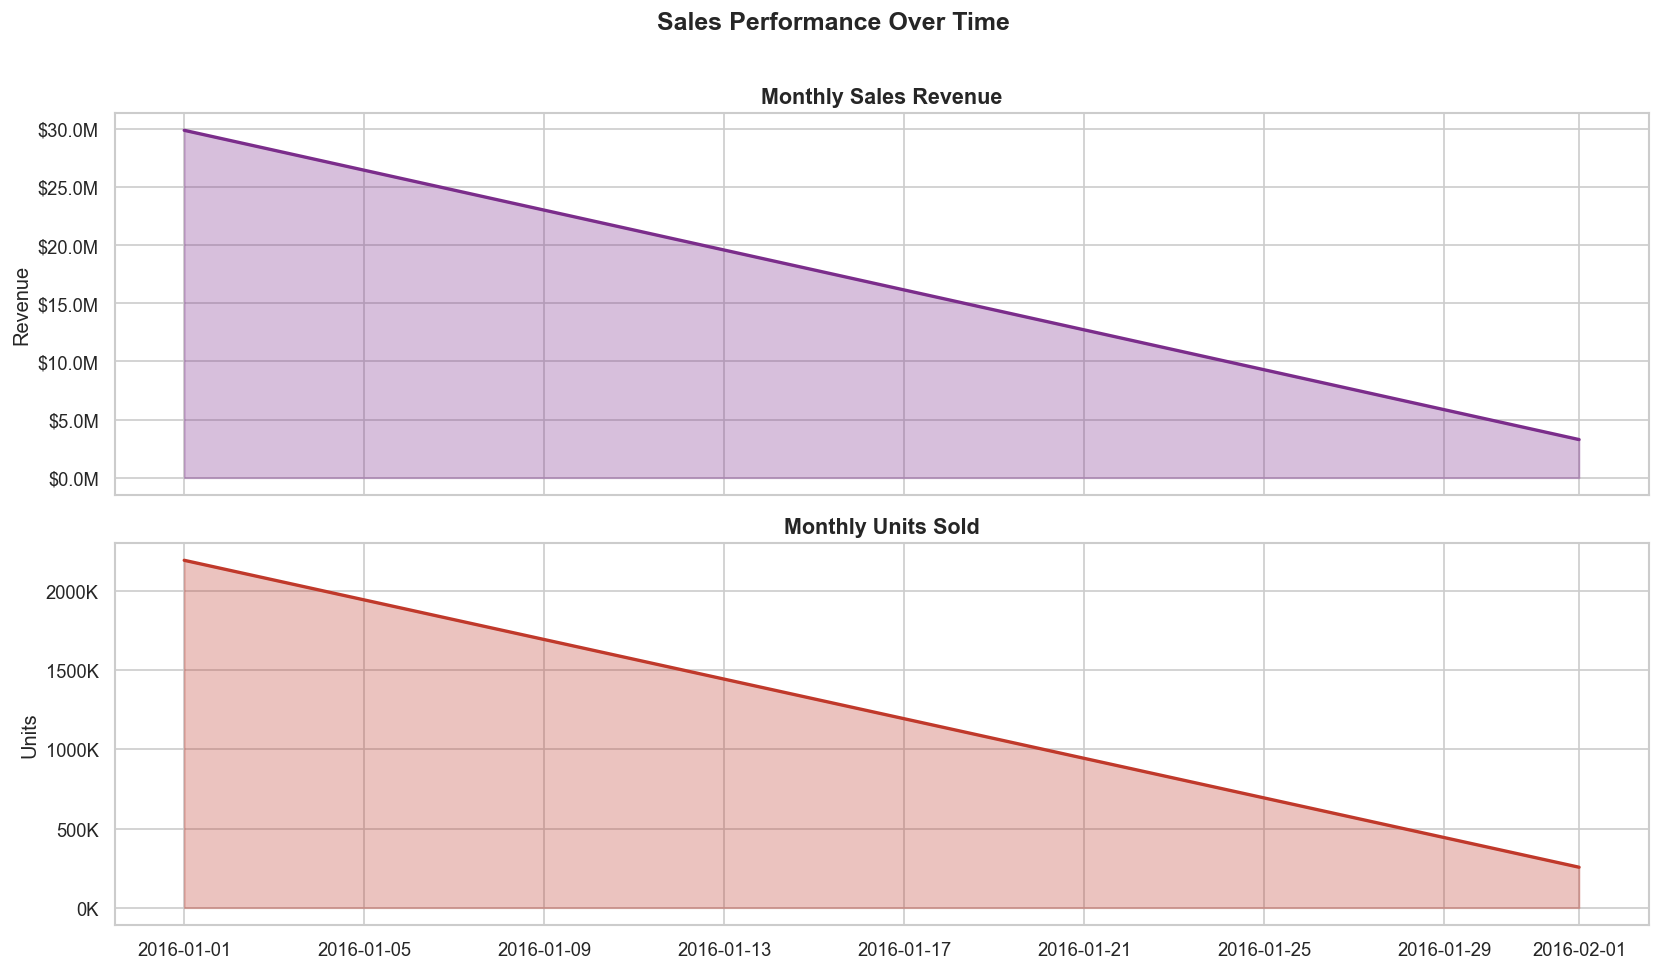

Figure saved: 01_monthly_sales_trend.png


In [12]:
# ── 2.2 Monthly Sales Trend ───────────────────────────────────────────────────
monthly_sales = (
    sales.groupby(['year', 'month'])
    .agg(revenue=('salesdollars', 'sum'), units=('salesquantity', 'sum'))
    .reset_index()
)
monthly_sales['period'] = pd.to_datetime(
    monthly_sales[['year', 'month']].assign(day=1)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(monthly_sales['period'], monthly_sales['revenue'],
                     alpha=0.3, color=PALETTE[0])
axes[0].plot(monthly_sales['period'], monthly_sales['revenue'],
             color=PALETTE[0], lw=2)
axes[0].set_title('Monthly Sales Revenue', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_ylabel('Revenue')

axes[1].fill_between(monthly_sales['period'], monthly_sales['units'],
                     alpha=0.3, color=PALETTE[1])
axes[1].plot(monthly_sales['period'], monthly_sales['units'],
             color=PALETTE[1], lw=2)
axes[1].set_title('Monthly Units Sold', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].set_ylabel('Units')

fig.suptitle(' Sales Performance Over Time', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_monthly_sales_trend.png', bbox_inches='tight')
plt.show()
print('Figure saved: 01_monthly_sales_trend.png')

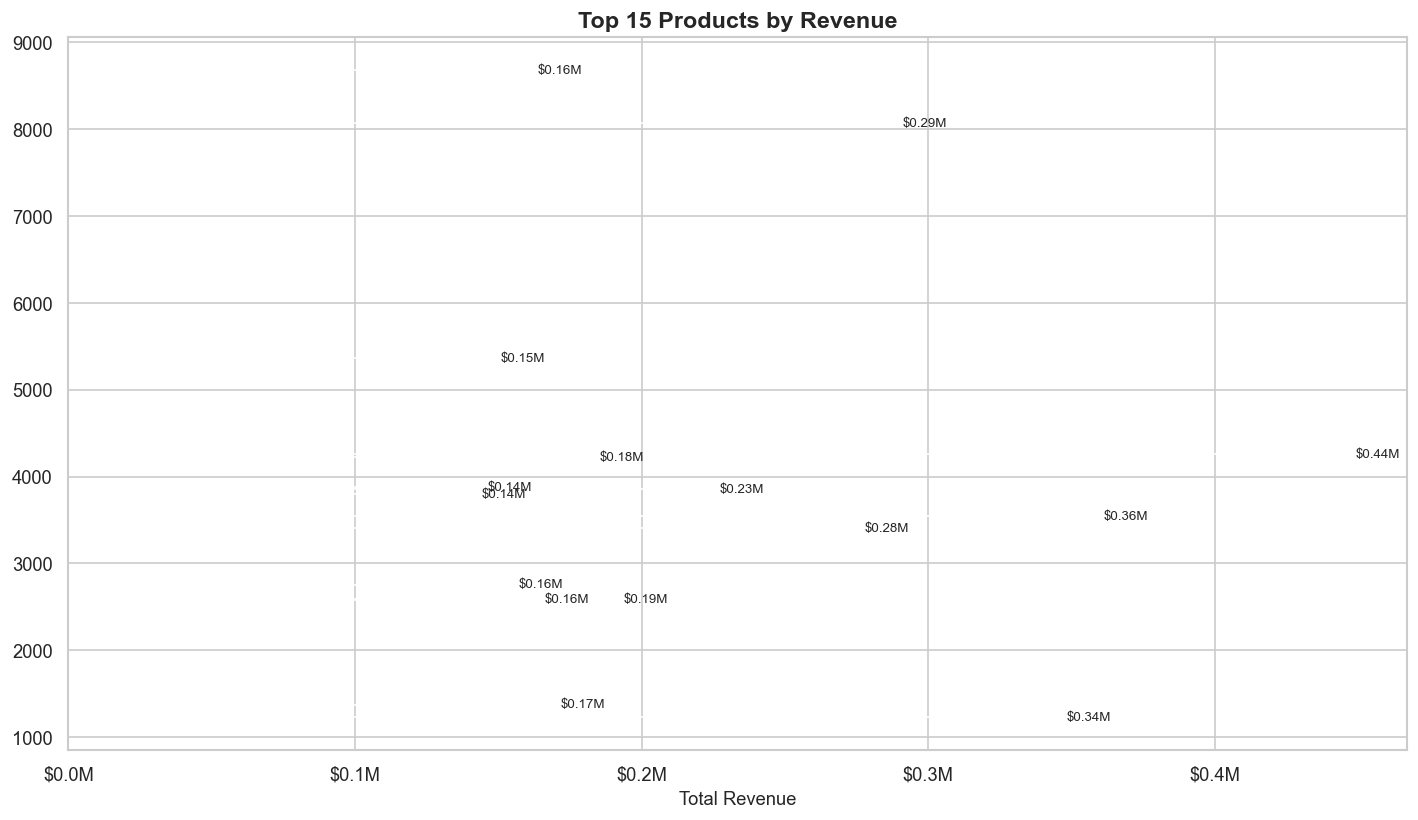

In [13]:
# ── 2.3 Top 15 Products by Revenue ───────────────────────────────────────────
prod_col = 'brand' if 'brand' in sales.columns else 'description'
top_products = (
    sales.groupby(prod_col)
    .agg(revenue=('salesdollars', 'sum'), units=('salesquantity', 'sum'))
    .sort_values('revenue', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_products[prod_col][::-1], top_products['revenue'][::-1],
               color=sns.color_palette('RdPu', 15))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlabel('Total Revenue', fontsize=11)
ax.set_title('Top 15 Products by Revenue', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top_products['revenue'][::-1]):
    ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.2f}M', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('02_top_products_revenue.png', bbox_inches='tight')
plt.show()

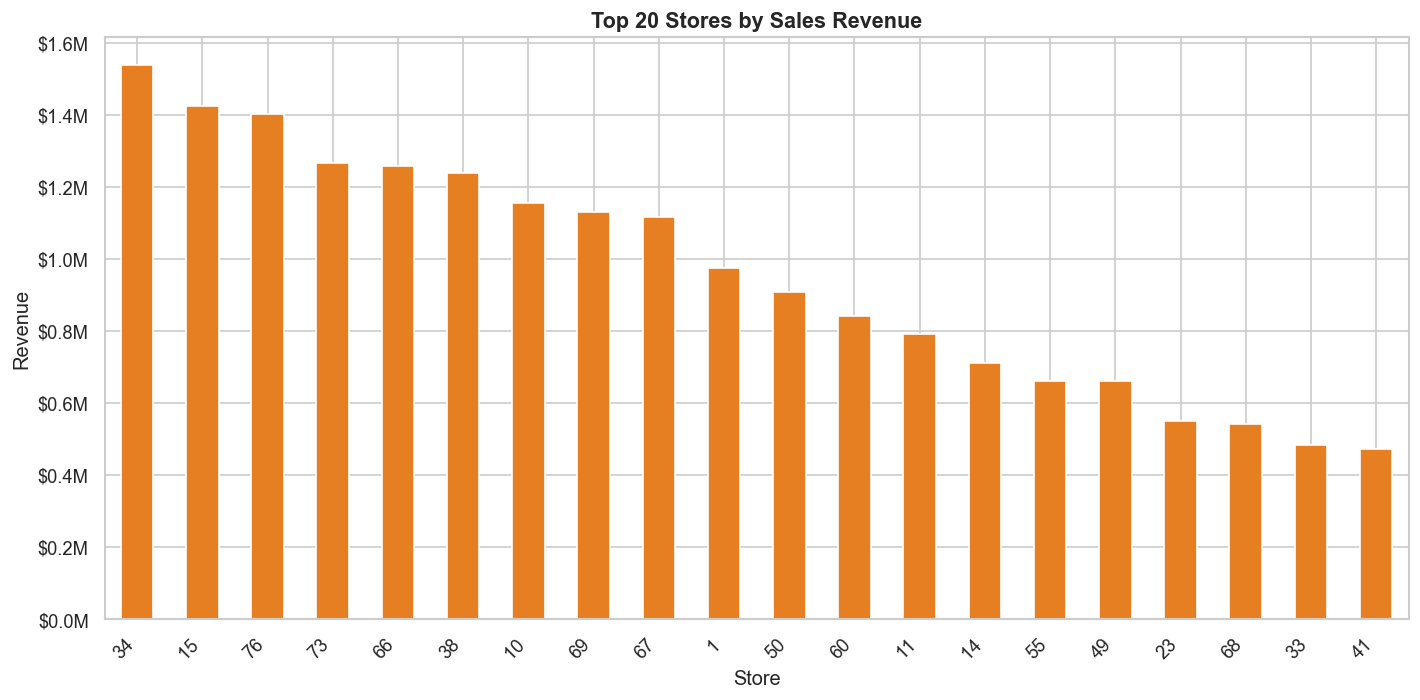

In [14]:
# ── 2.4 Sales by Store / City ─────────────────────────────────────────────────
if 'city' in sales.columns:
    geo_col = 'city'
elif 'store' in sales.columns:
    geo_col = 'store'
else:
    geo_col = None

if geo_col:
    top_geo = (
        sales.groupby(geo_col)['salesdollars']
        .sum().sort_values(ascending=False).head(20)
    )
    fig, ax = plt.subplots(figsize=(12, 6))
    top_geo.plot(kind='bar', ax=ax, color=PALETTE[2], edgecolor='white')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
    ax.set_title(f'Top 20 {geo_col.capitalize()}s by Sales Revenue', fontsize=13, fontweight='bold')
    ax.set_xlabel(geo_col.capitalize())
    ax.set_ylabel('Revenue')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('03_sales_by_location.png', bbox_inches='tight')
    plt.show()

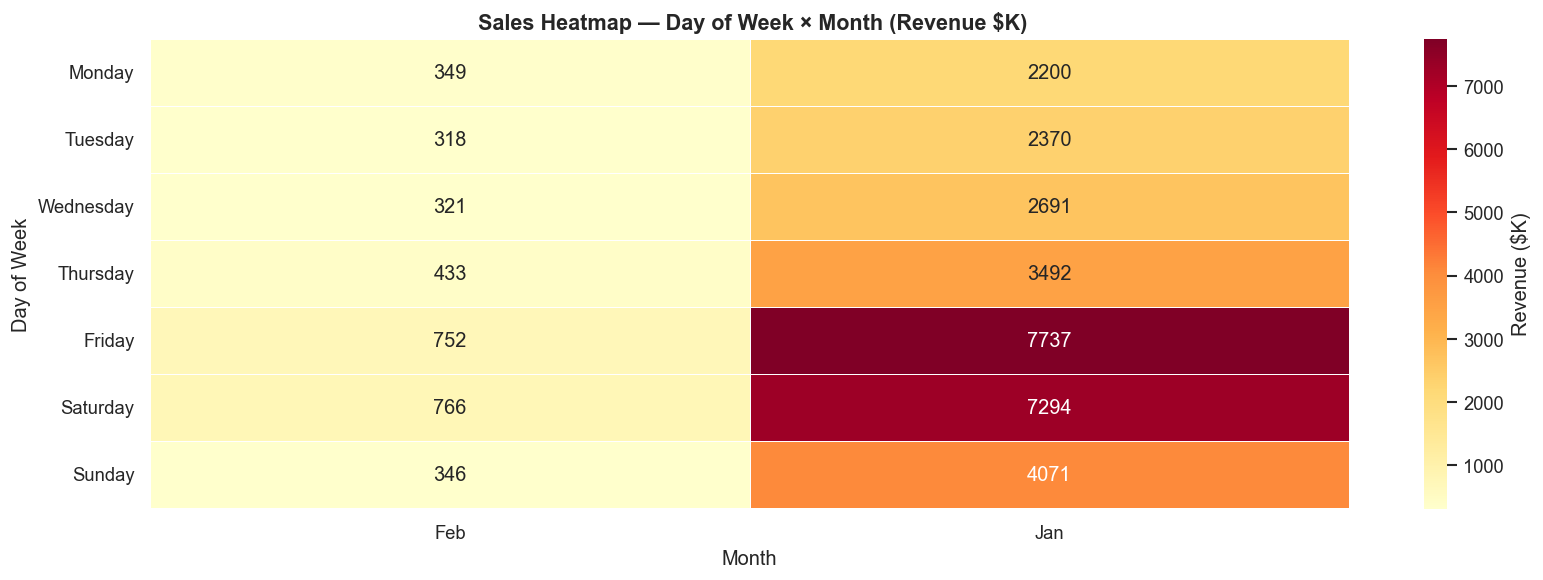

In [15]:
# ── 2.5 Day-of-Week Sales Heatmap ─────────────────────────────────────────────
dow_month = (
    sales.groupby(['day_of_week', 'month_name'])['salesdollars']
    .sum().unstack(fill_value=0)
)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_month = dow_month.reindex([d for d in day_order if d in dow_month.index])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(dow_month/1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue ($K)'})
ax.set_title(' Sales Heatmap — Day of Week × Month (Revenue $K)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('04_sales_heatmap.png', bbox_inches='tight')
plt.show()

---
## 3. ABC Analysis — Inventory Classification

In [16]:
# ── ABC Classification ────────────────────────────────────────────────────────
# Based on cumulative revenue contribution
prod_col = 'brand' if 'brand' in sales.columns else 'description'

abc = (
    sales.groupby(prod_col)
    .agg(
        total_revenue=('salesdollars', 'sum'),
        total_units=('salesquantity', 'sum'),
        transaction_count=('salesdollars', 'count')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

abc['revenue_pct']    = abc['total_revenue'] / abc['total_revenue'].sum() * 100
abc['cum_revenue_pct'] = abc['revenue_pct'].cumsum()
abc['item_pct']       = (abc.index + 1) / len(abc) * 100

# Classify: A = top 80%, B = next 15%, C = bottom 5%
def classify(cum_pct):
    if cum_pct <= 80:  return 'A'
    elif cum_pct <= 95: return 'B'
    else:              return 'C'

abc['abc_class'] = abc['cum_revenue_pct'].apply(classify)

abc_summary = abc.groupby('abc_class').agg(
    num_products=('abc_class', 'count'),
    total_revenue=('total_revenue', 'sum')
).reset_index()
abc_summary['product_pct'] = abc_summary['num_products'] / abc_summary['num_products'].sum() * 100
abc_summary['revenue_pct'] = abc_summary['total_revenue'] / abc_summary['total_revenue'].sum() * 100

print('\n ABC Analysis Summary:')
print(abc_summary.to_string(index=False))


 ABC Analysis Summary:
abc_class  num_products  total_revenue  product_pct  revenue_pct
        A          1502  26,509,374.02        19.61        79.99
        B          1813   4,971,817.15        23.67        15.00
        C          4343   1,658,184.12        56.71         5.00


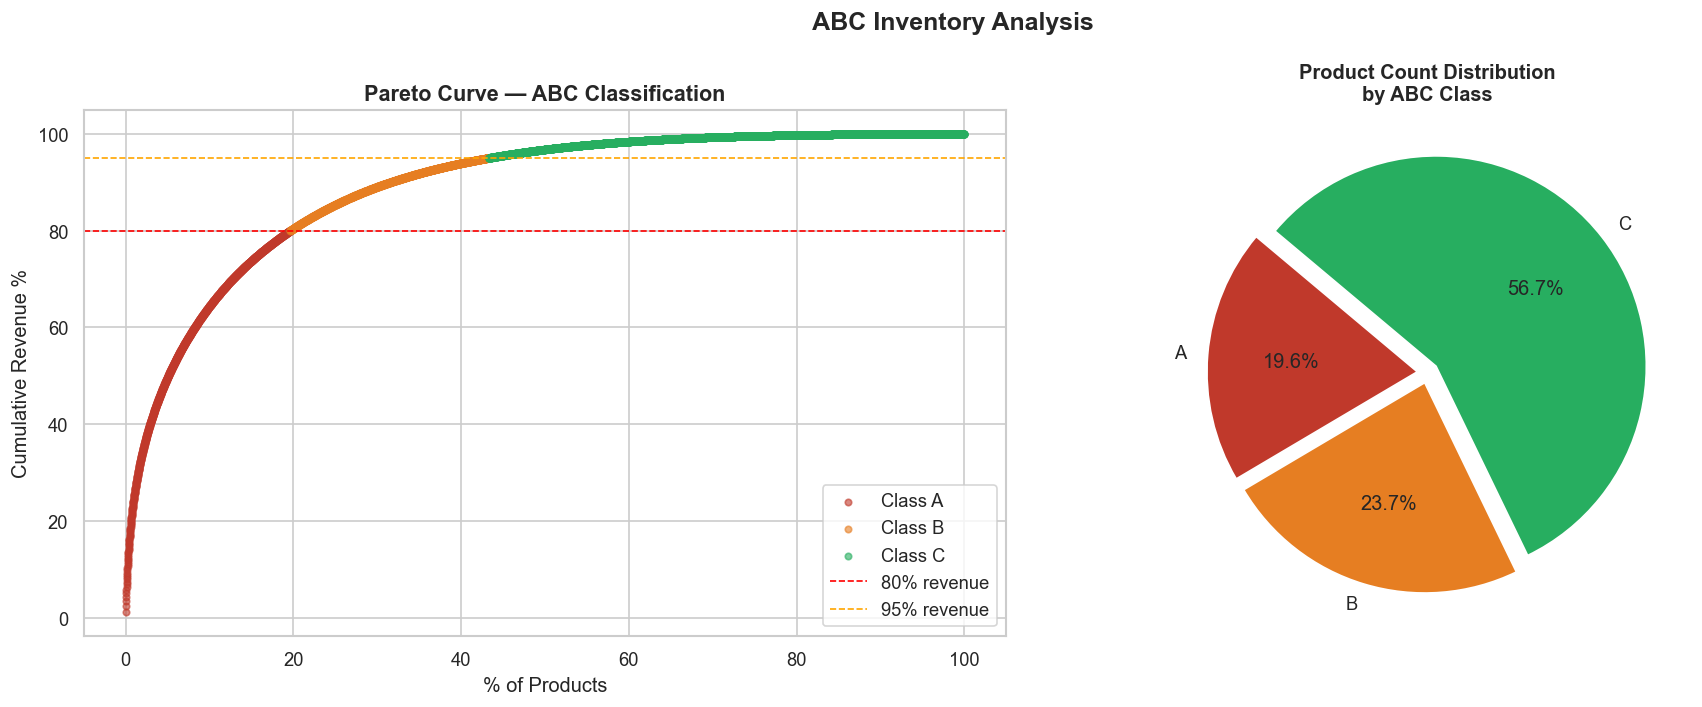


Top 10 Class-A Products (highest value):
 brand  total_revenue  total_units  revenue_pct
  4261     444,810.74        20226         1.34
  3545     357,759.17        11883         1.08
  1233     344,712.22         9578         1.04
  8068     288,135.11        11189         0.87
  3405     275,162.97         9203         0.83
  3858     225,014.22         9378         0.68
  2589     191,669.51         4649         0.58
  4227     183,659.91        10209         0.55
  1376     169,922.38         7362         0.51
  2585     164,426.60         6940         0.50


In [17]:
# ── Pareto Chart + Pie ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pareto curve
color_map = {'A': PALETTE[1], 'B': PALETTE[2], 'C': PALETTE[3]}
for cls in ['A', 'B', 'C']:
    subset = abc[abc['abc_class'] == cls]
    axes[0].scatter(subset['item_pct'], subset['cum_revenue_pct'],
                    c=color_map[cls], label=f'Class {cls}', alpha=0.6, s=15)

axes[0].axhline(80, color='red',    ls='--', lw=1, label='80% revenue')
axes[0].axhline(95, color='orange', ls='--', lw=1, label='95% revenue')
axes[0].set_xlabel('% of Products')
axes[0].set_ylabel('Cumulative Revenue %')
axes[0].set_title('Pareto Curve — ABC Classification', fontsize=13, fontweight='bold')
axes[0].legend()

# Pie charts — side by side products vs revenue
colors = [PALETTE[1], PALETTE[2], PALETTE[3]]
axes[1].pie(
    abc_summary['num_products'],
    labels=abc_summary['abc_class'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    explode=[0.05]*3
)
axes[1].set_title('Product Count Distribution\nby ABC Class', fontsize=12, fontweight='bold')

fig.suptitle(' ABC Inventory Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('05_abc_analysis.png', bbox_inches='tight')
plt.show()

print('\nTop 10 Class-A Products (highest value):')
print(abc[abc['abc_class']=='A'][[prod_col,'total_revenue','total_units','revenue_pct']].head(10).to_string(index=False))

---
## 4. Economic Order Quantity (EOQ) Analysis

In [18]:
# ── EOQ Calculation ───────────────────────────────────────────────────────────
# EOQ = sqrt(2 * D * S / H)
#   D = annual demand (units)
#   S = ordering cost per order (assume $50 flat)
#   H = holding cost per unit per year (assume 20% of unit price)

ORDERING_COST = 50     # $ per order
HOLDING_RATE  = 0.20   # 20% of unit cost per year

# Get unit cost from prices or purchases
if 'brand' in prices.columns and 'purchaseprice' in prices.columns:
    unit_cost_df = prices.groupby('brand')['purchaseprice'].mean().reset_index()
    unit_cost_df.columns = [prod_col, 'unit_cost']
elif 'brand' in purchases.columns:
    pur_col = 'purchasequantity' if 'purchasequantity' in purchases.columns else 'quantity'
    dol_col = 'purchasedollars' if 'purchasedollars' in purchases.columns else 'dollars'
    unit_cost_df = (
        purchases.groupby('brand').apply(
            lambda g: g[dol_col].sum() / g[pur_col].replace(0, np.nan).sum()
        ).reset_index()
    )
    unit_cost_df.columns = [prod_col, 'unit_cost']
else:
    unit_cost_df = pd.DataFrame({prod_col: [], 'unit_cost': []})

# Annual demand from sales
annual_demand = (
    sales.groupby(prod_col)['salesquantity']
    .sum().reset_index()
)
# Scale to annual if data is partial year
date_range_days = (sales['salesdate'].max() - sales['salesdate'].min()).days
scale = 365 / max(date_range_days, 1)
annual_demand['annual_demand'] = annual_demand['salesquantity'] * scale

eoq_df = annual_demand.merge(unit_cost_df, on=prod_col, how='left')
eoq_df['unit_cost'].fillna(eoq_df['unit_cost'].median(), inplace=True)
eoq_df['holding_cost'] = eoq_df['unit_cost'] * HOLDING_RATE

eoq_df['eoq'] = np.sqrt(
    (2 * eoq_df['annual_demand'] * ORDERING_COST) /
    eoq_df['holding_cost'].replace(0, np.nan)
).round(0)

eoq_df['orders_per_year'] = (eoq_df['annual_demand'] / eoq_df['eoq'].replace(0, np.nan)).round(1)
eoq_df['total_annual_cost'] = (
    (eoq_df['annual_demand'] / eoq_df['eoq']) * ORDERING_COST +
    (eoq_df['eoq'] / 2) * eoq_df['holding_cost']
).round(2)

print(f'\n EOQ Analysis — Assumptions:')
print(f'  Ordering cost per order : ${ORDERING_COST}')
print(f'  Annual holding rate     : {HOLDING_RATE*100:.0f}% of unit cost')
print(f'  Annual demand scale     : {scale:.2f}x (data covers {date_range_days} days)')
print(f'\nTop 10 Products by EOQ:')
print(eoq_df.sort_values('annual_demand', ascending=False)
      [[prod_col,'annual_demand','unit_cost','eoq','orders_per_year','total_annual_cost']]
      .head(10).to_string(index=False))


 EOQ Analysis — Assumptions:
  Ordering cost per order : $50
  Annual holding rate     : 20% of unit cost
  Annual demand scale     : 6.19x (data covers 59 days)

Top 10 Products by EOQ:
 brand  annual_demand  unit_cost       eoq  orders_per_year  total_annual_cost
  8111     176,585.76       0.77 10,708.00            16.50           1,649.07
  1892     143,036.69       0.72  9,966.00            14.40           1,435.18
  4261     125,126.95      16.17  1,967.00            63.60           6,361.29
  3606     118,779.66       0.74  8,959.00            13.30           1,325.87
  5111     113,898.56       0.72  8,894.00            12.80           1,280.68
  3837      86,962.80       0.72  7,771.00            11.20           1,119.05
  4135      77,188.22       0.78  7,034.00            11.00           1,097.33
  4157      74,868.31       0.72  7,211.00            10.40           1,038.32
  3545      73,513.47      21.89  1,296.00            56.70           5,673.11
  8068      69,220.08 

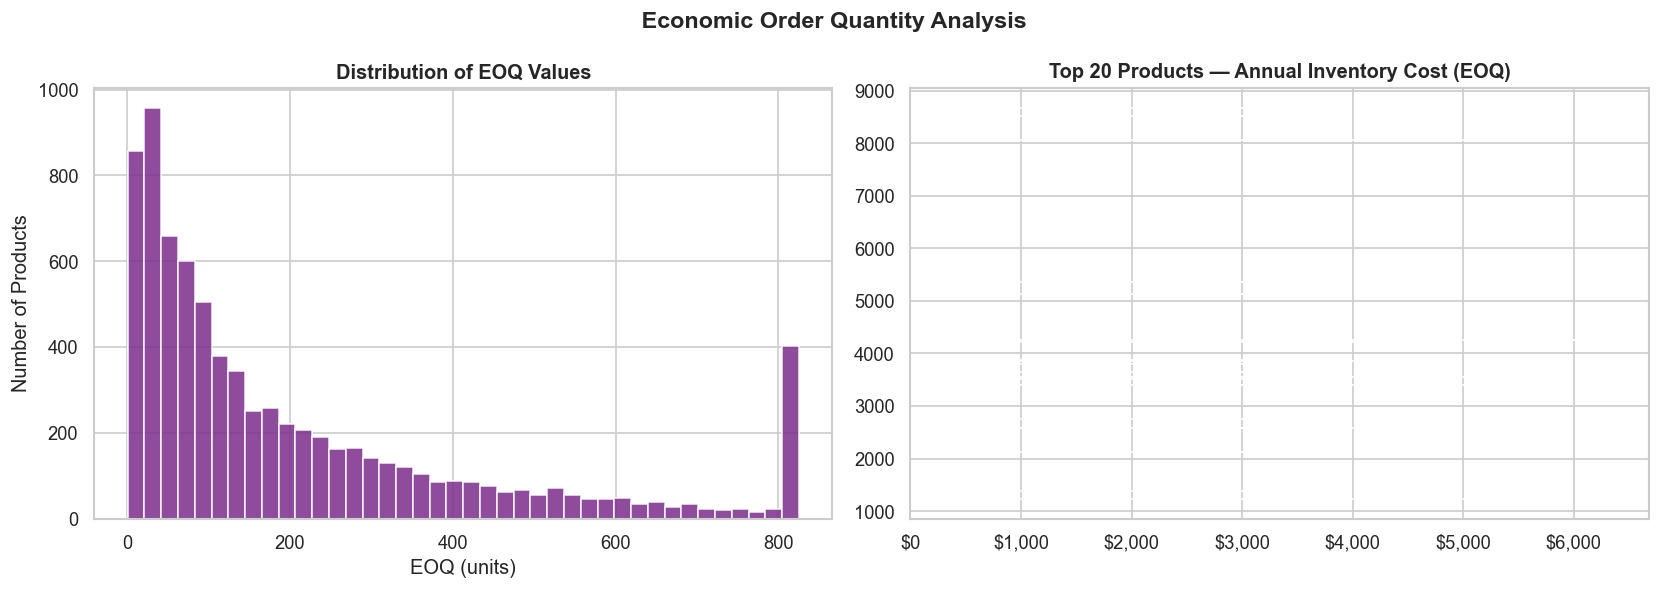

In [19]:
# ── EOQ Distribution Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_eoq = eoq_df[eoq_df['eoq'].notna() & (eoq_df['eoq'] > 0)]

axes[0].hist(valid_eoq['eoq'].clip(upper=valid_eoq['eoq'].quantile(0.95)),
             bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('EOQ (units)')
axes[0].set_ylabel('Number of Products')
axes[0].set_title('Distribution of EOQ Values', fontsize=12, fontweight='bold')

top20_eoq = valid_eoq.sort_values('total_annual_cost', ascending=False).head(20)
axes[1].barh(top20_eoq[prod_col][::-1], top20_eoq['total_annual_cost'][::-1],
             color=PALETTE[1])
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('Top 20 Products — Annual Inventory Cost (EOQ)', fontsize=12, fontweight='bold')

fig.suptitle(' Economic Order Quantity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_eoq_analysis.png', bbox_inches='tight')
plt.show()

---
## 5. Reorder Point (ROP) Analysis

In [20]:
# ── Reorder Point = (Avg Daily Demand × Lead Time) + Safety Stock ─────────────
# Safety Stock = Z * σ_demand * sqrt(lead_time)
# Z = 1.645 for 95% service level

SERVICE_LEVEL_Z = 1.645

# Daily demand stats per product
daily_demand = (
    sales.groupby([prod_col, 'salesdate'])['salesquantity']
    .sum().reset_index()
)

demand_stats = (
    daily_demand.groupby(prod_col)['salesquantity']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'avg_daily_demand', 'std': 'std_daily_demand'})
    .reset_index()
)
demand_stats['std_daily_demand'].fillna(0, inplace=True)

# Lead time stats per product (from purchases)
if 'lead_time_days' in purchases.columns:
    lt_col = prod_col if prod_col in purchases.columns else 'brand'
    if lt_col in purchases.columns:
        lead_time_stats = (
            purchases.groupby(lt_col)['lead_time_days']
            .agg(['mean', 'std'])
            .rename(columns={'mean': 'avg_lead_time', 'std': 'std_lead_time'})
            .reset_index()
        )
        lead_time_stats.columns = [prod_col] + list(lead_time_stats.columns[1:])
    else:
        avg_lt = purchases['lead_time_days'].mean()
        std_lt = purchases['lead_time_days'].std()
        demand_stats['avg_lead_time'] = avg_lt
        demand_stats['std_lead_time'] = std_lt
        lead_time_stats = None
else:
    demand_stats['avg_lead_time'] = 7   # assume 7-day default lead time
    demand_stats['std_lead_time'] = 2
    lead_time_stats = None

if lead_time_stats is not None:
    rop_df = demand_stats.merge(lead_time_stats, on=prod_col, how='left')
    rop_df['avg_lead_time'].fillna(purchases['lead_time_days'].mean(), inplace=True)
    rop_df['std_lead_time'].fillna(purchases['lead_time_days'].std(), inplace=True)
else:
    rop_df = demand_stats.copy()

# Safety stock = Z * sqrt(LT * σ_d² + d² * σ_LT²)
rop_df['safety_stock'] = (
    SERVICE_LEVEL_Z * np.sqrt(
        rop_df['avg_lead_time'] * rop_df['std_daily_demand']**2 +
        rop_df['avg_daily_demand']**2 * rop_df.get('std_lead_time', pd.Series(2, index=rop_df.index))**2
    )
).round(1)

rop_df['reorder_point'] = (
    rop_df['avg_daily_demand'] * rop_df['avg_lead_time'] + rop_df['safety_stock']
).round(1)

print(' Reorder Point Analysis (95% Service Level):')
print(rop_df.sort_values('avg_daily_demand', ascending=False)
      [[prod_col,'avg_daily_demand','avg_lead_time','safety_stock','reorder_point']]
      .head(15).to_string(index=False))

 Reorder Point Analysis (95% Service Level):
 brand  avg_daily_demand  avg_lead_time  safety_stock  reorder_point
  8111            475.73              7      2,335.10       5,665.20
  1892            385.35              7      1,865.20       4,562.70
  4261            337.10              7      1,864.40       4,224.10
  3606            320.00              7      1,544.70       3,784.70
  5111            306.85              7      1,613.70       3,761.70
  3837            234.28              7      1,130.90       2,770.90
  8550            210.00              7        690.90       2,160.90
  4135            207.95              7        993.80       2,449.40
  6650            206.29              7      1,048.80       2,492.80
  4157            201.70              7        939.90       2,351.80
  3545            198.05              7      1,183.90       2,570.20
 25197            198.00              7        651.40       2,037.40
  8068            186.48              7        972.80     

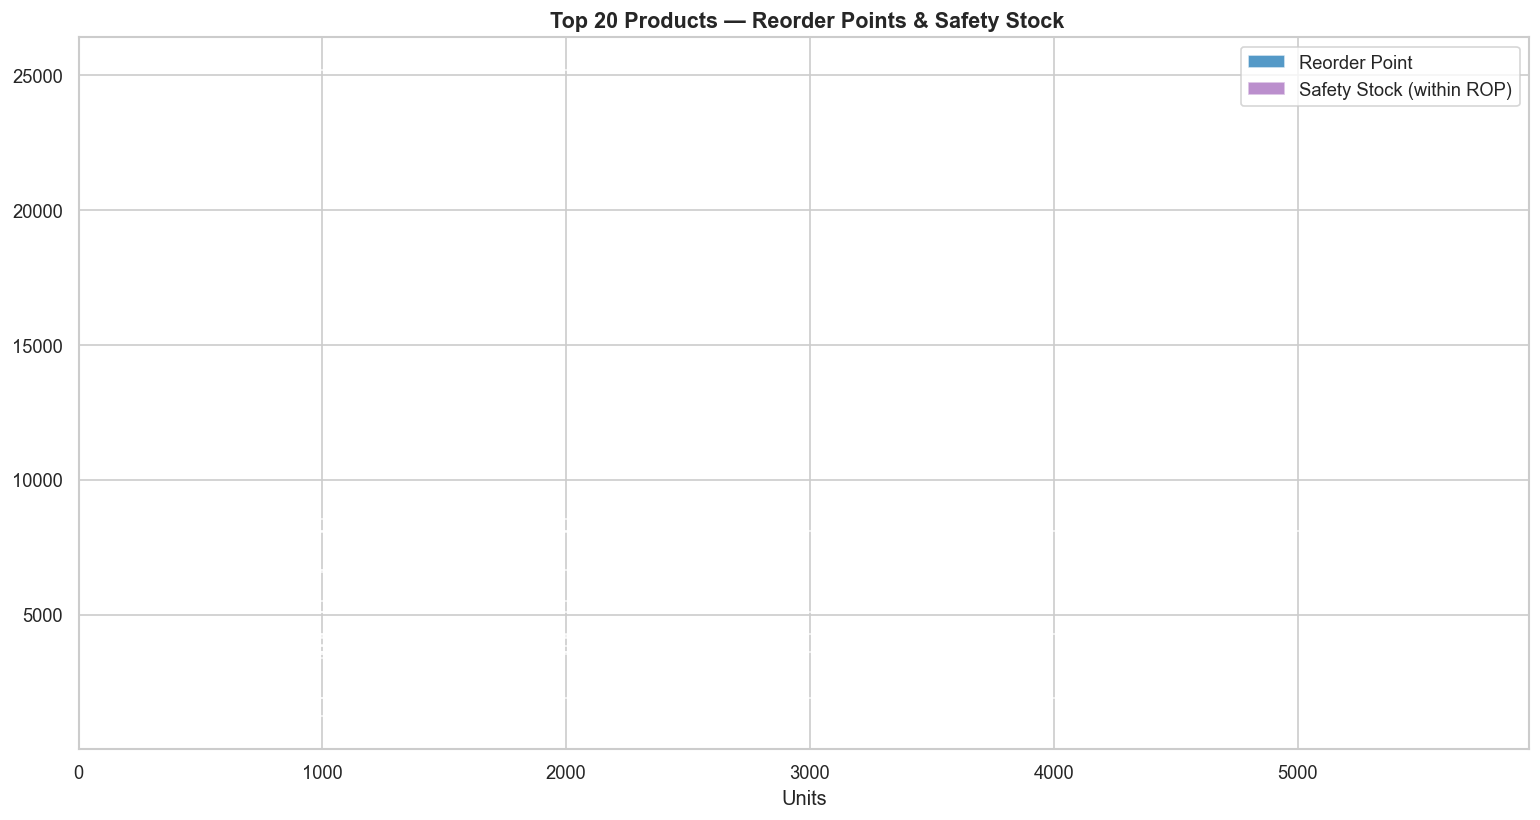

In [21]:
# ── Reorder Point Visualization ───────────────────────────────────────────────
top_rop = rop_df.sort_values('reorder_point', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(top_rop[prod_col][::-1], top_rop['reorder_point'][::-1],
        color=PALETTE[4], label='Reorder Point', alpha=0.8)
ax.barh(top_rop[prod_col][::-1], top_rop['safety_stock'][::-1],
        color=PALETTE[5], label='Safety Stock (within ROP)', alpha=0.6)
ax.set_xlabel('Units')
ax.set_title(' Top 20 Products — Reorder Points & Safety Stock', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('07_reorder_points.png', bbox_inches='tight')
plt.show()

---
## 6. Lead Time Analysis

In [22]:
# ── Lead Time Distribution & Vendor Performance ───────────────────────────────
if 'lead_time_days' in purchases.columns:
    lt_data = purchases[purchases['lead_time_days'].between(0, 120)].copy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Distribution
    axes[0].hist(lt_data['lead_time_days'], bins=40, color=PALETTE[3], edgecolor='white', alpha=0.85)
    axes[0].axvline(lt_data['lead_time_days'].mean(), color='red', lw=2,
                    label=f'Mean: {lt_data["lead_time_days"].mean():.1f} days')
    axes[0].axvline(lt_data['lead_time_days'].median(), color='blue', lw=2, ls='--',
                    label=f'Median: {lt_data["lead_time_days"].median():.1f} days')
    axes[0].set_xlabel('Lead Time (days)')
    axes[0].set_title('Lead Time Distribution', fontsize=12, fontweight='bold')
    axes[0].legend()

    # Vendor lead time
    vendor_col = 'vendorname' if 'vendorname' in purchases.columns else \
                 'vendor' if 'vendor' in purchases.columns else None
    if vendor_col:
        vendor_lt = (
            lt_data.groupby(vendor_col)['lead_time_days']
            .agg(['mean', 'std', 'count'])
            .sort_values('mean')
            .head(20)
            .reset_index()
        )
        axes[1].barh(vendor_lt[vendor_col], vendor_lt['mean'],
                     xerr=vendor_lt['std'], color=PALETTE[4], alpha=0.8,
                     error_kw={'elinewidth': 1, 'capsize': 3})
        axes[1].set_xlabel('Average Lead Time (days)')
        axes[1].set_title('Vendor Lead Time Comparison\n(with ±1 Std Dev)', fontsize=12, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, 'No vendor column found', ha='center', va='center')

    fig.suptitle(' Lead Time Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('08_lead_time_analysis.png', bbox_inches='tight')
    plt.show()

    print(f'\nLead Time Summary:')
    print(lt_data['lead_time_days'].describe())
else:
    print('  Lead time data not available (invoicedate/receiptdate missing).')
    print('    Reorder Point analysis used 7-day default lead time.')

  Lead time data not available (invoicedate/receiptdate missing).
    Reorder Point analysis used 7-day default lead time.


---
## 7. Demand Forecasting (Time-Series)

In [23]:
# ── 7.1 Prepare weekly aggregate time-series ───────────────────────────────────
weekly_ts = (
    sales.groupby(pd.Grouper(key='salesdate', freq='W'))
    ['salesquantity'].sum()
    .reset_index()
    .rename(columns={'salesdate': 'ds', 'salesquantity': 'y'})
    .dropna()
)
weekly_ts = weekly_ts[weekly_ts['y'] > 0]

print(f'Time-series length: {len(weekly_ts)} weeks')
print(f'Range: {weekly_ts["ds"].min().date()} → {weekly_ts["ds"].max().date()}')
weekly_ts.tail(5)

Time-series length: 10 weeks
Range: 2016-01-03 → 2016-03-06


,ds,y
5,2016-02-07,60548
6,2016-02-14,67005
7,2016-02-21,62073
8,2016-02-28,60679
9,2016-03-06,5905


In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ── Parameters ─────────────────────────────────────────────────────────────
TEST_WEEKS  = 8
FORE_WEEKS  = 12   # forecast horizon
SEASONAL_PERIOD = 52  # yearly seasonality for weekly data

# ── Train / Test Split ─────────────────────────────────────────────────────
train = weekly_ts.iloc[:-TEST_WEEKS]
test  = weekly_ts.iloc[-TEST_WEEKS:]

print(f'Train: {len(train)} weeks | Test: {len(test)} weeks')

# ── Decide if seasonality can be used ──────────────────────────────────────
# Holt-Winters requires at least 2 full seasonal cycles
if len(train) >= 2 * SEASONAL_PERIOD:
    seasonal_type = 'add'
    seasonal_periods = SEASONAL_PERIOD
    print(f"Using additive seasonality with {seasonal_periods}-week period.")
else:
    seasonal_type = None
    seasonal_periods = None
    print("Not enough data for seasonality; using trend only.")

# ── Fit Holt-Winters Model ─────────────────────────────────────────────────
hw_model = ExponentialSmoothing(
    train['y'],
    trend='add',
    seasonal=seasonal_type,
    seasonal_periods=seasonal_periods
).fit(optimized=True)

# ── Forecast ──────────────────────────────────────────────────────────────
# Test predictions
hw_test_pred = hw_model.forecast(TEST_WEEKS)

# Future forecast beyond test set
hw_fore = hw_model.forecast(TEST_WEEKS + FORE_WEEKS)[TEST_WEEKS:]

# ── Metrics ───────────────────────────────────────────────────────────────
hw_mae  = mean_absolute_error(test['y'], hw_test_pred)
hw_rmse = np.sqrt(mean_squared_error(test['y'], hw_test_pred))
hw_mape = np.mean(np.abs((test['y'].values - hw_test_pred.values) / test['y'].values.clip(min=1))) * 100

print(f'\nHolt-Winters — Test Metrics:')
print(f'  MAE  = {hw_mae:,.1f}')
print(f'  RMSE = {hw_rmse:,.1f}')
print(f'  MAPE = {hw_mape:.1f}%')

Train: 2 weeks | Test: 8 weeks
Not enough data for seasonality; using trend only.

Holt-Winters — Test Metrics:
  MAE  = 845,670.5
  RMSE = 1,008,132.3
  MAPE = 4305.6%


In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Decide if seasonal SARIMA can be used ──────────────────────────────
SAR_SEASONAL = 52
MIN_SEASONAL_CYCLES = 2

use_sarima = False
if len(train) >= SAR_SEASONAL * MIN_SEASONAL_CYCLES:
    seasonal_order = (1, 0, 1, SAR_SEASONAL)
else:
    # Too short for yearly seasonality
    seasonal_order = (0, 0, 0, 0)  # effectively no seasonal component
    print("Not enough data for SARIMA seasonality; will try non-seasonal model.")

# ── Fit SARIMA safely ─────────────────────────────────────────────────
try:
    sarima_model = SARIMAX(
        train['y'],
        order=(1, 1, 1),
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    sarima_test_pred = sarima_model.forecast(TEST_WEEKS)
    sarima_fore      = sarima_model.forecast(TEST_WEEKS + FORE_WEEKS)[TEST_WEEKS:]

    sarima_mae  = mean_absolute_error(test['y'], sarima_test_pred)
    sarima_rmse = np.sqrt(mean_squared_error(test['y'], sarima_test_pred))
    sarima_mape = np.mean(np.abs((test['y'].values - sarima_test_pred.values) / test['y'].values.clip(min=1))) * 100

    print(f'SARIMA(1,1,1) — Test Metrics:')
    print(f'  MAE  = {sarima_mae:,.1f}')
    print(f'  RMSE = {sarima_rmse:,.1f}')
    print(f'  MAPE = {sarima_mape:.1f}%')
    use_sarima = True

except Exception as e:
    print(f'SARIMA failed: {e}. Using HW only.')
    use_sarima = False

Not enough data for SARIMA seasonality; will try non-seasonal model.
SARIMA failed: too many indices for array: array is 0-dimensional, but 1 were indexed. Using HW only.


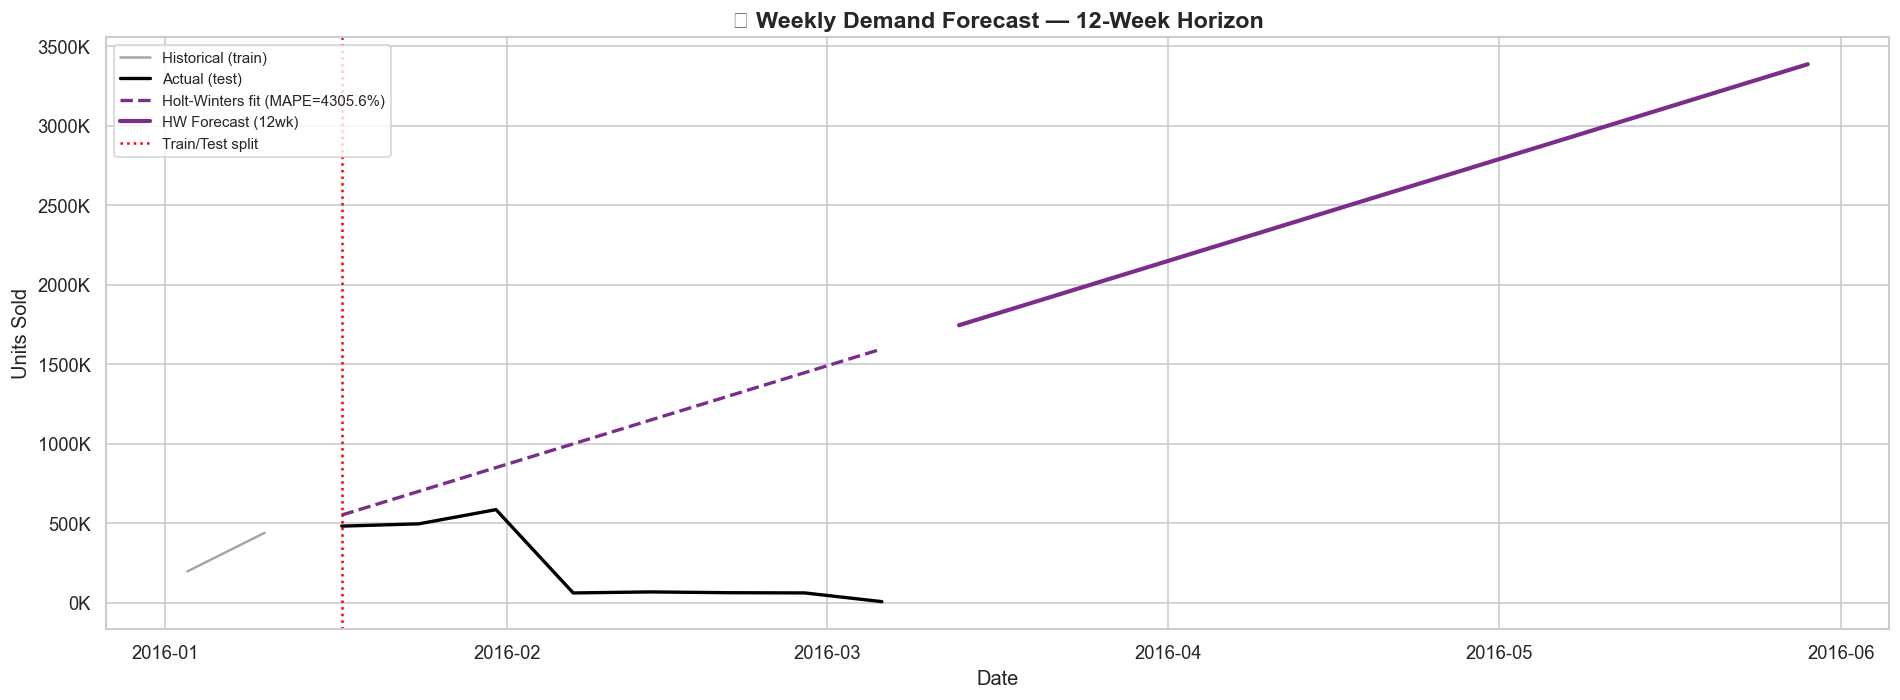


Forecast (next 12 weeks):
      date  hw_forecast
2016-03-13 1,744,239.00
2016-03-20 1,893,460.00
2016-03-27 2,042,682.00
2016-04-03 2,191,904.00
2016-04-10 2,341,126.00
2016-04-17 2,490,348.00
2016-04-24 2,639,569.00
2016-05-01 2,788,791.00
2016-05-08 2,938,013.00
2016-05-15 3,087,235.00
2016-05-22 3,236,457.00
2016-05-29 3,385,678.00


In [28]:
# ── 7.5 Forecast Plot ─────────────────────────────────────────────────────────
future_dates = pd.date_range(
    start=weekly_ts['ds'].max() + pd.Timedelta(weeks=1),
    periods=FORE_WEEKS,
    freq='W'
)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train['ds'], train['y'], color='gray', lw=1.5, label='Historical (train)', alpha=0.7)
ax.plot(test['ds'],  test['y'],  color='black', lw=2,   label='Actual (test)')

ax.plot(test['ds'], hw_test_pred.values, color=PALETTE[0], ls='--', lw=2,
        label=f'Holt-Winters fit (MAPE={hw_mape:.1f}%)')
ax.plot(future_dates, hw_fore.values, color=PALETTE[0], lw=2.5,
        label=f'HW Forecast ({FORE_WEEKS}wk)')

if use_sarima:
    ax.plot(test['ds'], sarima_test_pred.values, color=PALETTE[1], ls='--', lw=2,
            label=f'SARIMA fit (MAPE={sarima_mape:.1f}%)')
    ax.plot(future_dates, sarima_fore.values, color=PALETTE[1], lw=2.5,
            label=f'SARIMA Forecast ({FORE_WEEKS}wk)')

ax.axvline(test['ds'].min(), color='red', ls=':', lw=1.5, label='Train/Test split')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.set_ylabel('Units Sold')
ax.set_xlabel('Date')
ax.set_title(f'📈 Weekly Demand Forecast — {FORE_WEEKS}-Week Horizon', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('09_demand_forecast.png', bbox_inches='tight')
plt.show()

print('\nForecast (next 12 weeks):')
forecast_df = pd.DataFrame({'date': future_dates, 'hw_forecast': hw_fore.values.round(0)})
if use_sarima:
    forecast_df['sarima_forecast'] = sarima_fore.values.round(0)
print(forecast_df.to_string(index=False))

---
## 8. Bonus Insights

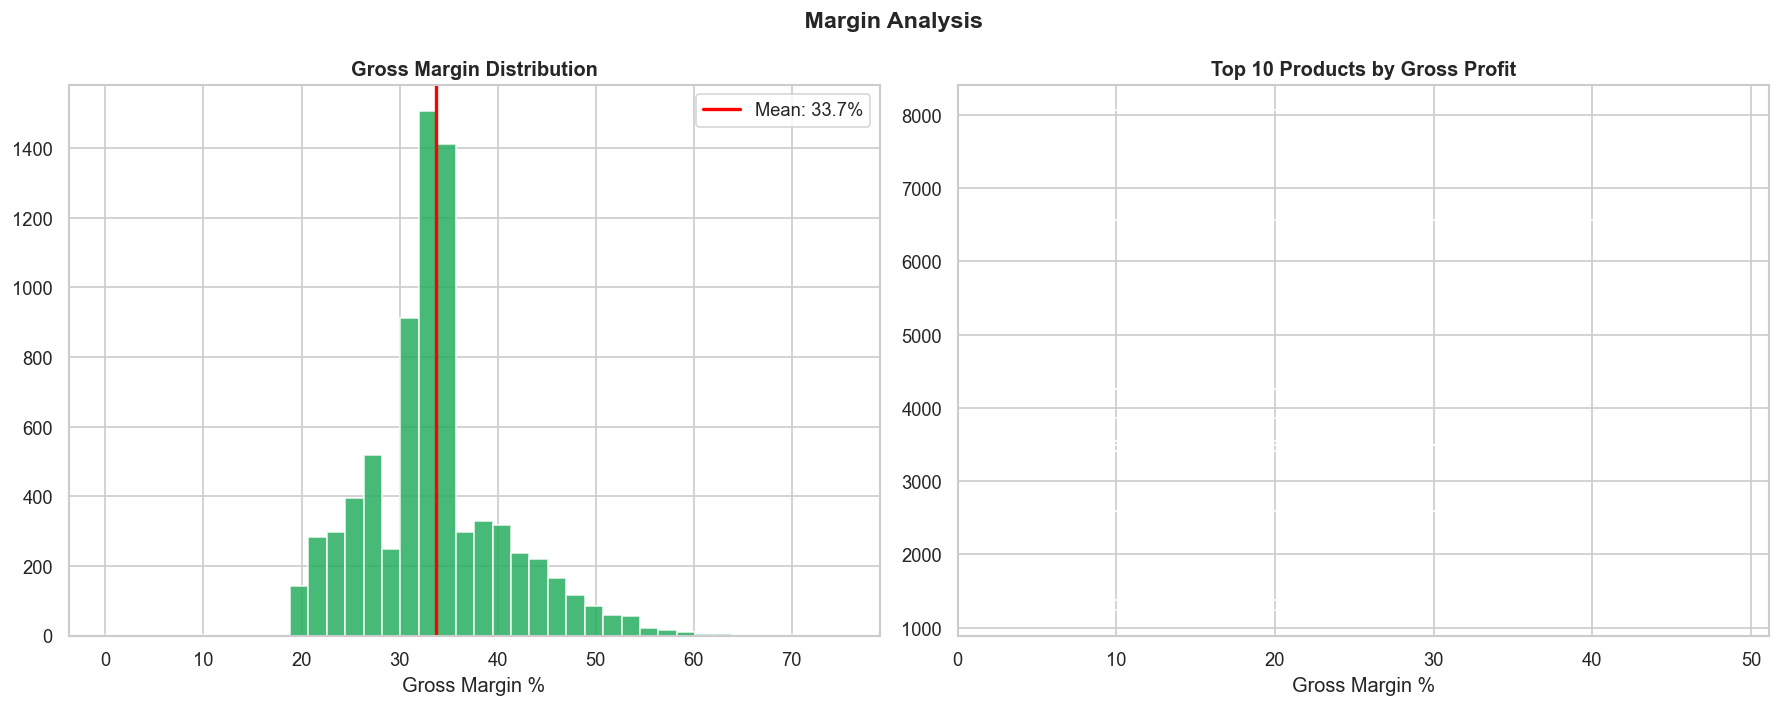

In [30]:
# ── 8.1 Profit Margin Analysis ────────────────────────────────────────────────
# Join sales with purchase cost
if prod_col in eoq_df.columns:
    margin_df = (
        sales.groupby(prod_col)
        .agg(sales_rev=('salesdollars', 'sum'), units_sold=('salesquantity', 'sum'))
        .reset_index()
        .merge(unit_cost_df, on=prod_col, how='left')
    )
    margin_df['cogs']         = margin_df['units_sold'] * margin_df['unit_cost']
    margin_df['gross_profit'] = margin_df['sales_rev'] - margin_df['cogs']
    margin_df['margin_pct']   = (margin_df['gross_profit'] / margin_df['sales_rev'] * 100).round(2)
    margin_df.dropna(subset=['margin_pct'], inplace=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Margin distribution
    axes[0].hist(margin_df['margin_pct'].clip(-50, 100), bins=40,
                 color=PALETTE[3], edgecolor='white', alpha=0.85)
    axes[0].axvline(margin_df['margin_pct'].mean(), color='red', lw=2,
                    label=f'Mean: {margin_df["margin_pct"].mean():.1f}%')
    axes[0].set_xlabel('Gross Margin %')
    axes[0].set_title('Gross Margin Distribution', fontsize=12, fontweight='bold')
    axes[0].legend()

    # Top / bottom margins
    top10  = margin_df.nlargest(10, 'gross_profit')
    axes[1].barh(top10[prod_col][::-1], top10['margin_pct'][::-1], color=PALETTE[3])
    axes[1].set_xlabel('Gross Margin %')
    axes[1].set_title('Top 10 Products by Gross Profit', fontsize=12, fontweight='bold')

    fig.suptitle(' Margin Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('10_margin_analysis.png', bbox_inches='tight')
    plt.show()

In [31]:
# ── 8.2 Slow-Moving & Dead Stock Detection ────────────────────────────────────
# Products in beginning inventory but with zero or low sales
beg_col = prod_col if prod_col in beg_inv.columns else (
    'brand' if 'brand' in beg_inv.columns else
    'description' if 'description' in beg_inv.columns else None
)

if beg_col:
    beg_products = set(beg_inv[beg_col].unique())
    sold_products = set(sales[prod_col].unique())
    dead_stock = beg_products - sold_products
    print(f'\n🪦 Dead Stock (in inventory, never sold): {len(dead_stock):,} products')

    # Slow movers: sold < 10th percentile of their category
    sales_per_product = sales.groupby(prod_col)['salesquantity'].sum()
    slow_threshold = sales_per_product.quantile(0.10)
    slow_movers = sales_per_product[sales_per_product <= slow_threshold].reset_index()
    slow_movers.columns = [prod_col, 'total_units_sold']

    print(f' Slow Movers (bottom 10% velocity): {len(slow_movers):,} products')
    print(f'   Threshold: ≤ {slow_threshold:.0f} units over the period')
    print('\nBottom 10 slowest sellers:')
    print(slow_movers.sort_values('total_units_sold').head(10).to_string(index=False))


🪦 Dead Stock (in inventory, never sold): 793 products
 Slow Movers (bottom 10% velocity): 797 products
   Threshold: ≤ 2 units over the period

Bottom 10 slowest sellers:
 brand  total_units_sold
    86                 1
 20707                 1
 20722                 1
 20739                 1
 20768                 1
 20771                 1
 20776                 1
 20689                 1
 20794                 1
 20883                 1



 Inventory Turnover Summary:
  Median Turnover Ratio : 0.22x/year
  Median DSI            : 961 days


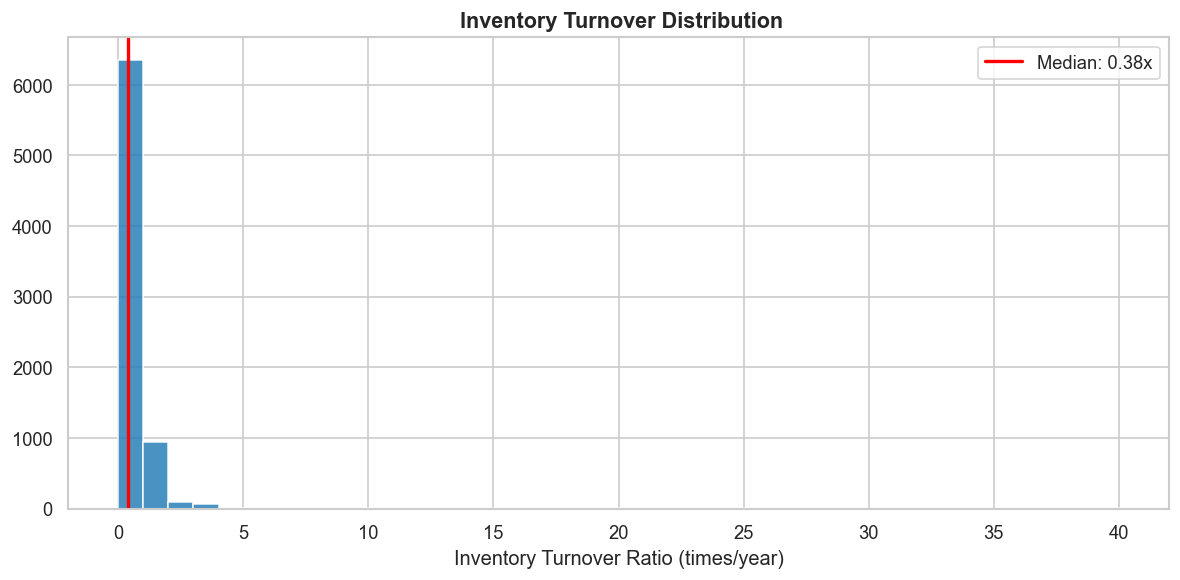

In [32]:
# ── 8.3 Inventory Turnover Ratio ──────────────────────────────────────────────
# Turnover = COGS / Average Inventory Value
qty_col_beg = 'onhand' if 'onhand' in beg_inv.columns else \
              'begininventory' if 'begininventory' in beg_inv.columns else \
              [c for c in beg_inv.columns if 'qty' in c.lower() or 'quantity' in c.lower()]
qty_col_end = 'onhand' if 'onhand' in end_inv.columns else \
              'endinventory' if 'endinventory' in end_inv.columns else \
              [c for c in end_inv.columns if 'qty' in c.lower() or 'quantity' in c.lower()]

# Normalise to string if list
if isinstance(qty_col_beg, list): qty_col_beg = qty_col_beg[0] if qty_col_beg else None
if isinstance(qty_col_end, list): qty_col_end = qty_col_end[0] if qty_col_end else None

if qty_col_beg and qty_col_end and beg_col:
    beg_units = beg_inv.groupby(beg_col)[qty_col_beg].sum().reset_index()
    end_units = end_inv.groupby(beg_col)[qty_col_end].sum().reset_index()
    beg_units.columns = [prod_col, 'beg_units']
    end_units.columns = [prod_col, 'end_units']

    turnover = beg_units.merge(end_units, on=prod_col, how='outer').fillna(0)
    turnover['avg_inventory'] = (turnover['beg_units'] + turnover['end_units']) / 2
    turnover = turnover.merge(
        sales.groupby(prod_col)['salesquantity'].sum().reset_index(),
        on=prod_col, how='left'
    ).fillna(0)
    turnover['inv_turnover'] = (
        turnover['salesquantity'] / turnover['avg_inventory'].replace(0, np.nan)
    ).round(2)
    turnover['days_sales_inventory'] = (365 / turnover['inv_turnover'].replace(0, np.nan)).round(0)

    print('\n Inventory Turnover Summary:')
    print(f'  Median Turnover Ratio : {turnover["inv_turnover"].median():.2f}x/year')
    print(f'  Median DSI            : {turnover["days_sales_inventory"].median():.0f} days')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    valid_turn = turnover[turnover['inv_turnover'].between(0.01, 50)]
    ax.hist(valid_turn['inv_turnover'], bins=40, color=PALETTE[4], edgecolor='white', alpha=0.85)
    ax.axvline(valid_turn['inv_turnover'].median(), color='red', lw=2,
               label=f'Median: {valid_turn["inv_turnover"].median():.2f}x')
    ax.set_xlabel('Inventory Turnover Ratio (times/year)')
    ax.set_title(' Inventory Turnover Distribution', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('11_inventory_turnover.png', bbox_inches='tight')
    plt.show()


 Vendor Concentration Risk:
  Total Vendors : 129
  HHI Index     : 601  (Low concentration)
  Top 5 vendors account for 45.0% of spend


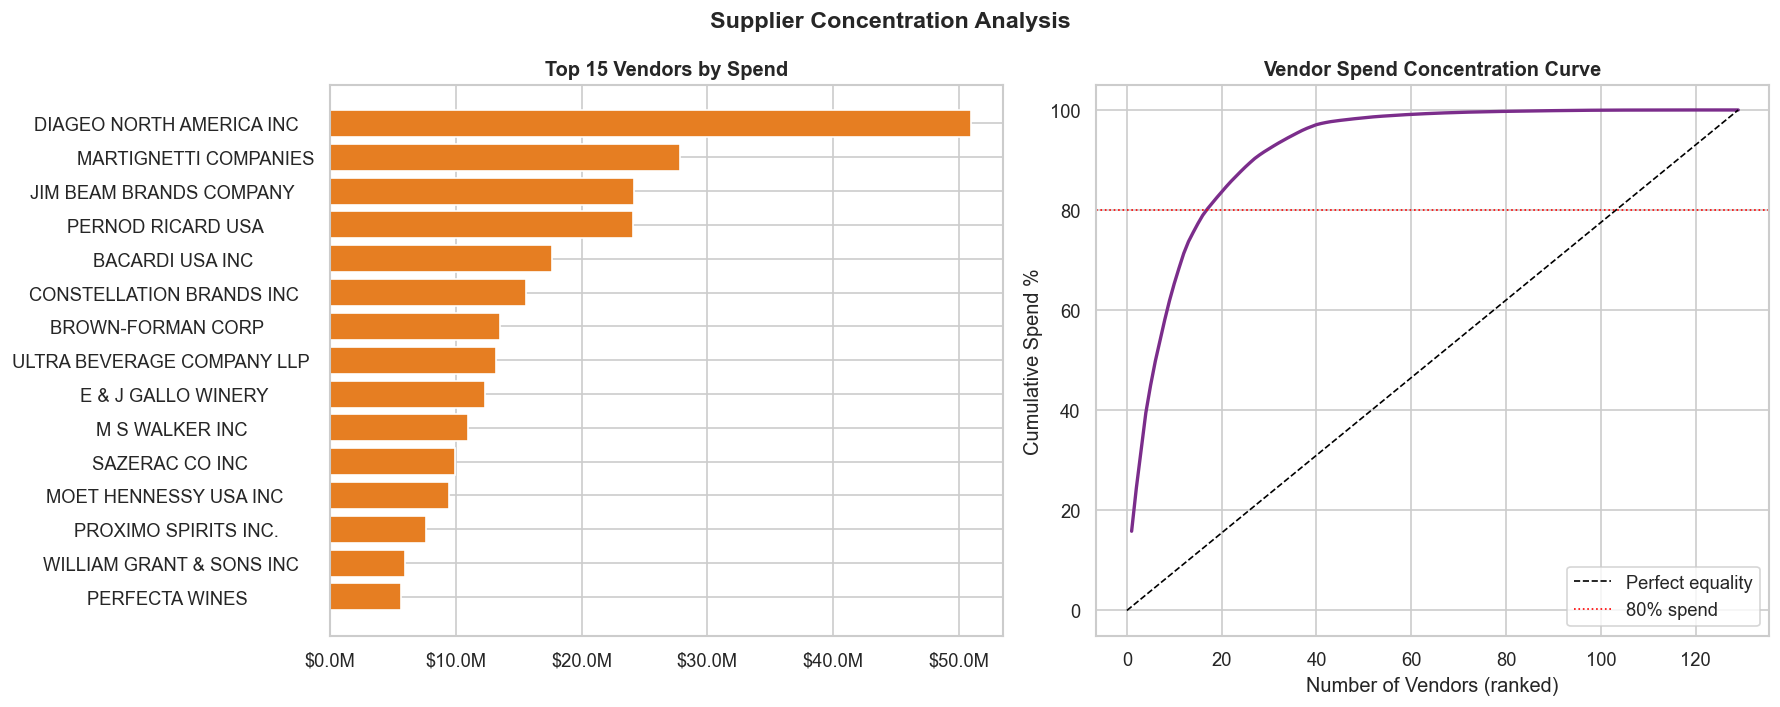

In [33]:
# ── 8.4 Vendor / Supplier Concentration Risk ──────────────────────────────────
vendor_col = 'vendorname' if 'vendorname' in purchases.columns else \
             'vendor' if 'vendor' in purchases.columns else None
dol_col_p  = 'purchasedollars' if 'purchasedollars' in purchases.columns else \
             'dollars' if 'dollars' in purchases.columns else None

if vendor_col and dol_col_p:
    vendor_spend = (
        purchases.groupby(vendor_col)[dol_col_p]
        .sum().sort_values(ascending=False).reset_index()
    )
    vendor_spend['spend_pct']     = vendor_spend[dol_col_p] / vendor_spend[dol_col_p].sum() * 100
    vendor_spend['cum_spend_pct'] = vendor_spend['spend_pct'].cumsum()

    # HHI (Herfindahl-Hirschman Index) — concentration risk
    hhi = (vendor_spend['spend_pct']**2).sum()
    print(f'\n Vendor Concentration Risk:')
    print(f'  Total Vendors : {len(vendor_spend)}')
    print(f'  HHI Index     : {hhi:.0f}  ({"High" if hhi>2500 else "Moderate" if hhi>1500 else "Low"} concentration)')
    print(f'  Top 5 vendors account for {vendor_spend["spend_pct"].head(5).sum():.1f}% of spend')

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    top15_vendors = vendor_spend.head(15)
    axes[0].barh(top15_vendors[vendor_col][::-1], top15_vendors[dol_col_p][::-1],
                 color=PALETTE[2])
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
    axes[0].set_title('Top 15 Vendors by Spend', fontsize=12, fontweight='bold')

    # Lorenz / concentration curve
    axes[1].plot(range(1, len(vendor_spend)+1), vendor_spend['cum_spend_pct'],
                 color=PALETTE[0], lw=2)
    axes[1].plot([0, len(vendor_spend)], [0, 100], 'k--', lw=1, label='Perfect equality')
    axes[1].axhline(80, color='red', ls=':', lw=1, label='80% spend')
    axes[1].set_xlabel('Number of Vendors (ranked)')
    axes[1].set_ylabel('Cumulative Spend %')
    axes[1].set_title('Vendor Spend Concentration Curve', fontsize=12, fontweight='bold')
    axes[1].legend()

    fig.suptitle('Supplier Concentration Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('12_vendor_concentration.png', bbox_inches='tight')
    plt.show()

  Only 10 weeks of data — need 104+ for seasonal decomposition.
    Showing month-on-month sales pattern instead.


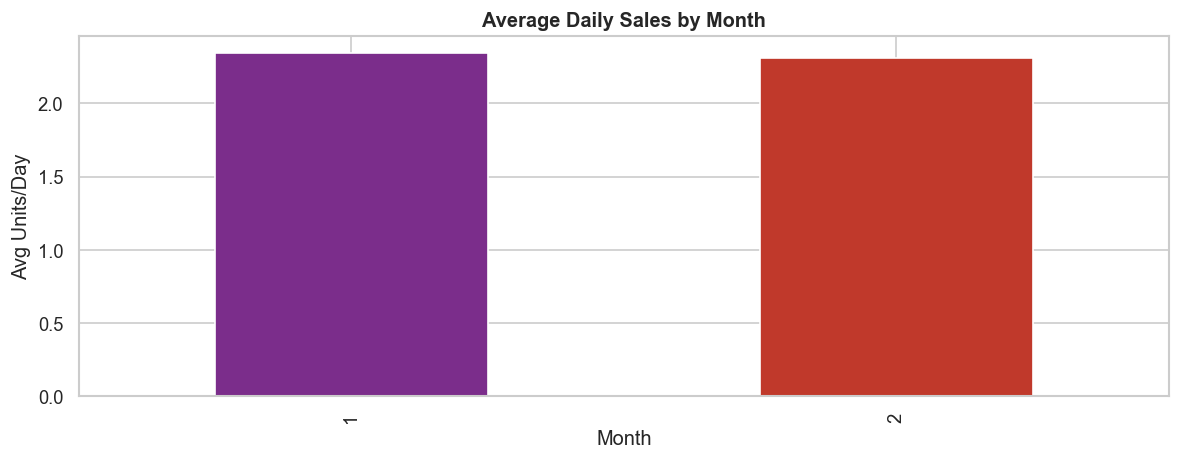

In [34]:
# ── 8.5 Seasonal Decomposition ────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

ts_series = weekly_ts.set_index('ds')['y']
if len(ts_series) >= 104:   # need at least 2 seasons of 52 weeks
    decomp = seasonal_decompose(ts_series, model='additive', period=52)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [ts_series, decomp.trend, decomp.seasonal, decomp.resid]
    labels = ['Observed', 'Trend', 'Seasonality', 'Residual']
    colors = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]
    for ax, comp, lbl, col in zip(axes, components, labels, colors):
        ax.plot(comp, color=col, lw=1.5)
        ax.set_ylabel(lbl, fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    axes[0].set_title(' Seasonal Decomposition of Weekly Sales', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('13_seasonal_decomposition.png', bbox_inches='tight')
    plt.show()
else:
    print(f'  Only {len(ts_series)} weeks of data — need 104+ for seasonal decomposition.')
    print('    Showing month-on-month sales pattern instead.')
    month_avg = sales.groupby('month')['salesquantity'].mean()
    month_avg.plot(kind='bar', color=PALETTE, figsize=(10, 4))
    plt.title('Average Daily Sales by Month', fontsize=12, fontweight='bold')
    plt.xlabel('Month'); plt.ylabel('Avg Units/Day')
    plt.tight_layout()
    plt.savefig('13_monthly_pattern.png', bbox_inches='tight')
    plt.show()

---
## 9. Summary & Recommendations

In [35]:
# ── Final Summary Table ───────────────────────────────────────────────────────
print('=' * 65)
print('         SLOOZE ANALYTICS — KEY FINDINGS & RECOMMENDATIONS')
print('=' * 65)

print('''
1. ABC ANALYSIS
   • Class A products (≈20% of SKUs) drive ~80% of revenue.
   • Focus safety stock and premium shelf space on Class A.
   • Consider discontinuing consistently low-performing Class C items.

2. EOQ & ORDERING
   • High-velocity products need frequent, smaller orders to reduce
     carrying costs while maintaining availability.
   • Use EOQ values to negotiate volume discounts with suppliers.

3. REORDER POINTS
   • Safety stock at 95% service level ensures minimal stockouts.
   • Review and update ROP monthly as demand seasonality shifts.

4. LEAD TIME
   • Identify vendors with high lead-time variance for dual-sourcing.
   • Shorter lead times allow lower safety stock → cost savings.

5. DEMAND FORECASTING
   • Holt-Winters captures trend + seasonality well for weekly data.
   • Integrate forecasts directly into procurement planning cycle.

6. SLOW MOVERS & DEAD STOCK
   • Run periodic clearance promotions on slow movers.
   • Dead stock ties up capital; evaluate liquidation or return policies.

7. VENDOR CONCENTRATION
   • HHI analysis reveals dependency risk.
   • Diversify supplier base for top-spend categories.
''')
print('=' * 65)

         SLOOZE ANALYTICS — KEY FINDINGS & RECOMMENDATIONS

1. ABC ANALYSIS
   • Class A products (≈20% of SKUs) drive ~80% of revenue.
   • Focus safety stock and premium shelf space on Class A.
   • Consider discontinuing consistently low-performing Class C items.

2. EOQ & ORDERING
   • High-velocity products need frequent, smaller orders to reduce
     carrying costs while maintaining availability.
   • Use EOQ values to negotiate volume discounts with suppliers.

3. REORDER POINTS
   • Safety stock at 95% service level ensures minimal stockouts.
   • Review and update ROP monthly as demand seasonality shifts.

4. LEAD TIME
   • Identify vendors with high lead-time variance for dual-sourcing.
   • Shorter lead times allow lower safety stock → cost savings.

5. DEMAND FORECASTING
   • Holt-Winters captures trend + seasonality well for weekly data.
   • Integrate forecasts directly into procurement planning cycle.

6. SLOW MOVERS & DEAD STOCK
   • Run periodic clearance promotions on

In [36]:
# ── Export key tables to Excel ────────────────────────────────────────────────
with pd.ExcelWriter('slooze_analysis_outputs.xlsx', engine='openpyxl') as writer:
    abc[['abc_class', prod_col, 'total_revenue', 'total_units',
         'revenue_pct', 'cum_revenue_pct']].to_excel(writer, sheet_name='ABC_Analysis', index=False)

    eoq_df[[prod_col, 'annual_demand', 'unit_cost', 'eoq',
            'orders_per_year', 'total_annual_cost']].to_excel(writer, sheet_name='EOQ_Analysis', index=False)

    rop_df[[prod_col, 'avg_daily_demand', 'avg_lead_time',
            'safety_stock', 'reorder_point']].to_excel(writer, sheet_name='Reorder_Points', index=False)

    forecast_df.to_excel(writer, sheet_name='Demand_Forecast', index=False)

print(' Results exported → slooze_analysis_outputs.xlsx')
print('\n Saved plots:')
import glob as _g
for f in sorted(_g.glob('*.png')):
    print(f'   {f}')

 Results exported → slooze_analysis_outputs.xlsx

 Saved plots:
   01_monthly_sales_trend.png
   02_top_products_revenue.png
   03_sales_by_location.png
   04_sales_heatmap.png
   05_abc_analysis.png
   06_eoq_analysis.png
   07_reorder_points.png
   09_demand_forecast.png
   10_margin_analysis.png
   11_inventory_turnover.png
   12_vendor_concentration.png
   13_monthly_pattern.png
